### Compute Drawdowns

In [91]:
import pandas as pd
me_m=pd.read_csv("Portfolios_Formed_on_ME_monthly_EW.csv",header=0,index_col=0,parse_dates=True,na_values=-99.99)
rets=me_m[["Lo 10","Hi 10"]]
rets.columns=["SmallCap","LargeCap"]
rets=rets/100

/tmp/ipykernel_36731/1717158143.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  me_m=pd.read_csv("Portfolios_Formed_on_ME_monthly_EW.csv",header=0,index_col=0,parse_dates=True,na_values=-99.99)


<Axes: >

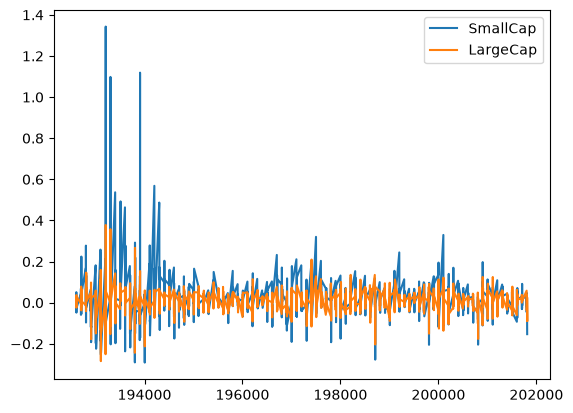

In [92]:
rets.plot.line()


In [93]:
rets.head()

,SmallCap,LargeCap
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270


In [94]:
rets.index

Index([192607, 192608, 192609, 192610, 192611, 192612, 192701, 192702, 192703,
       192704,
       ...
       201803, 201804, 201805, 201806, 201807, 201808, 201809, 201810, 201811,
       201812],
      dtype='int64', length=1110)

In [95]:
rets.index=pd.to_datetime(rets.index,format='%Y%m')

In [96]:
rets.index

DatetimeIndex(['1926-07-01', '1926-08-01', '1926-09-01', '1926-10-01',
               '1926-11-01', '1926-12-01', '1927-01-01', '1927-02-01',
               '1927-03-01', '1927-04-01',
               ...
               '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
               '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01',
               '2018-11-01', '2018-12-01'],
              dtype='datetime64[us]', length=1110, freq=None)

In [97]:
rets.head()

,SmallCap,LargeCap
1926-07-01,-0.0145,0.0329
1926-08-01,0.0512,0.0370
1926-09-01,0.0093,0.0067
1926-10-01,-0.0484,-0.0243
1926-11-01,-0.0078,0.0270


In [98]:
rets.index=rets.index.to_period('M')
rets.head()

,SmallCap,LargeCap
1926-07,-0.0145,0.0329
1926-08,0.0512,0.0370
1926-09,0.0093,0.0067
1926-10,-0.0484,-0.0243
1926-11,-0.0078,0.0270


In [99]:
rets.loc["1975"]

,SmallCap,LargeCap
1975-01,0.3202,0.1286
1975-02,0.0657,0.0613
1975-03,0.0989,0.0414
1975-04,0.0288,0.0531
1975-05,0.0811,0.0610
1975-06,0.0779,0.0524
1975-07,0.0218,-0.0703
1975-08,-0.0525,-0.0177
1975-09,-0.0351,-0.0468
1975-10,-0.0009,0.0620


In [100]:
rets.index

PeriodIndex(['1926-07', '1926-08', '1926-09', '1926-10', '1926-11', '1926-12',
             '1927-01', '1927-02', '1927-03', '1927-04',
             ...
             '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08',
             '2018-09', '2018-10', '2018-11', '2018-12'],
            dtype='period[M]', length=1110)

In [101]:
rets.info()

<class 'pandas.DataFrame'>
PeriodIndex: 1110 entries, 1926-07 to 2018-12
Freq: M
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SmallCap  1110 non-null   float64
 1   LargeCap  1110 non-null   float64
dtypes: float64(2)
memory usage: 26.0 KB


# Compute Drawdown 
1 Compute Wealth Index
2 Calculate the previous Peaks 
3 Compute the drawdown as the percentage of the previous peak

In [102]:
wealth_index=1000*(1+rets["LargeCap"]).cumprod()

In [103]:
wealth_index.head()

1926-07    1032.900000
1926-08    1071.117300
1926-09    1078.293786
1926-10    1052.091247
1926-11    1080.497711
Freq: M, Name: LargeCap, dtype: float64

<Axes: >

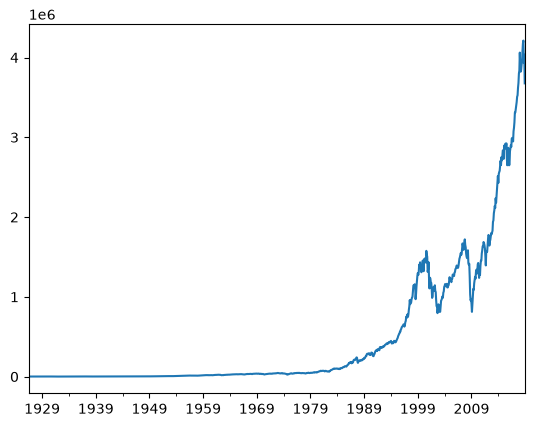

In [104]:
wealth_index.plot()

In [105]:
previous_peaks=wealth_index.cummax()

<Axes: >

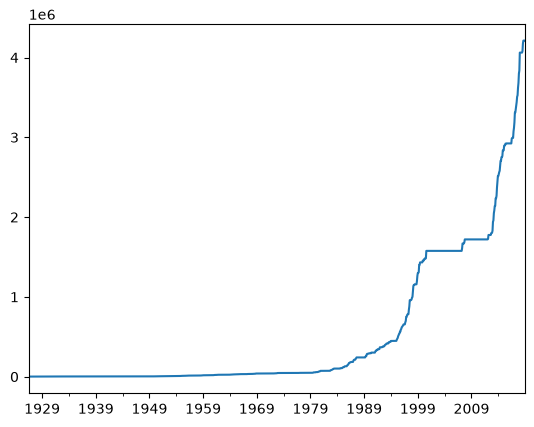

In [106]:
previous_peaks.plot()

In [107]:
drawdown=(wealth_index-previous_peaks)/previous_peaks

<Axes: >

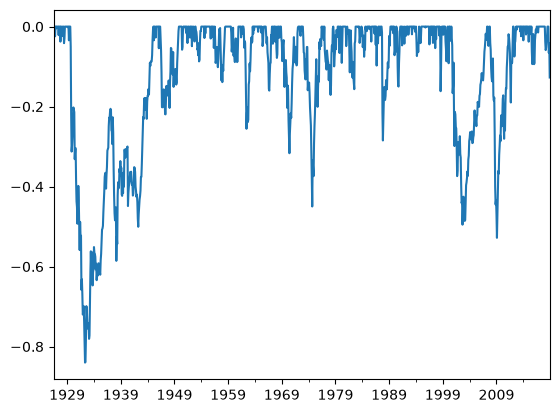

In [108]:
drawdown.plot()

In [109]:
drawdown.head()

1926-07    0.0000
1926-08    0.0000
1926-09    0.0000
1926-10   -0.0243
1926-11    0.0000
Freq: M, Name: LargeCap, dtype: float64

In [110]:
drawdown.min()

np.float64(-0.8400375277943123)

In [111]:
drawdown["1975":].idxmin()

Period('2009-02', 'M')

In [112]:
drawdown.idxmin()

Period('1932-05', 'M')

In [113]:
def drawdown(return_series: pd.Series):
    """
    Take the time series of asset returns
    Computes and returns a DataFrame That contains
    Wealth Index
    The previous peaks 
    percent drawdowns
    """
    wealth_index=1000*(1+return_series).cumprod()
    previous_peaks=wealth_index.cummax()
    drawdown=wealth_index-previous_peaks/previous_peaks
    return pd.DataFrame({
        "Wealth":wealth_index,
        "Peaks":previous_peaks,
        "Drawdown":drawdown
    })

In [114]:
drawdown(rets["LargeCap"]).head()

,Wealth,Peaks,Drawdown
1926-07,1032.900000,1032.900000,1031.900000
1926-08,1071.117300,1071.117300,1070.117300
1926-09,1078.293786,1078.293786,1077.293786
1926-10,1052.091247,1078.293786,1051.091247
1926-11,1080.497711,1080.497711,1079.497711


In [115]:
drawdown(rets["LargeCap"])[["Wealth","Peaks"]].head()

,Wealth,Peaks
1926-07,1032.900000,1032.900000
1926-08,1071.117300,1071.117300
1926-09,1078.293786,1078.293786
1926-10,1052.091247,1078.293786
1926-11,1080.497711,1080.497711


<Axes: >

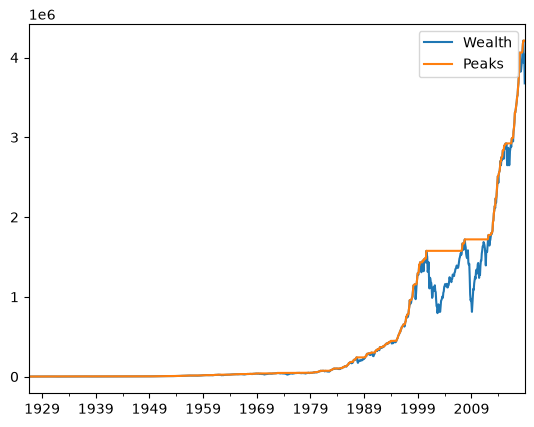

In [116]:
drawdown(rets["LargeCap"])[["Wealth","Peaks"]].plot()

<Axes: >

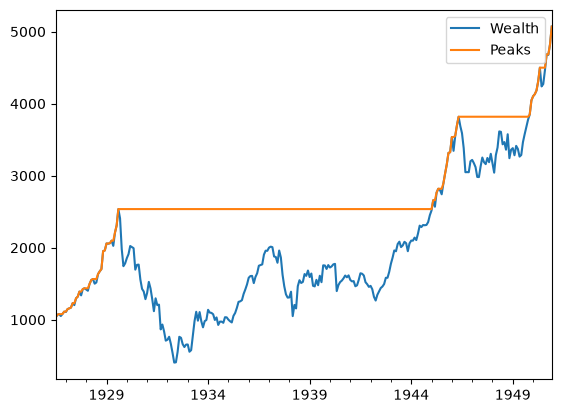

In [117]:
drawdown(rets.loc[:"1950"]["LargeCap"])[["Wealth","Peaks"]].plot()

In [118]:
drawdown(rets["LargeCap"]).head()

,Wealth,Peaks,Drawdown
1926-07,1032.900000,1032.900000,1031.900000
1926-08,1071.117300,1071.117300,1070.117300
1926-09,1078.293786,1078.293786,1077.293786
1926-10,1052.091247,1078.293786,1051.091247
1926-11,1080.497711,1080.497711,1079.497711


In [123]:
drawdown(rets["LargeCap"])["Drawdown"].min()

np.float64(404.76910202523374)

In [124]:
drawdown(rets["SmallCap"])["Drawdown"].min()

np.float64(490.2403230922996)